---
# Imports
---

In [1]:
# General Imports
import numpy as np
import seaborn as sns
from pathlib import Path
from ase.io import read, write
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ase imports
import abtem
from ase import Atoms
from ase.build import molecule
from ase.visualize import view
from ase.visualize.plot import plot_atoms
from ase.cluster import wulff_construction
abtem.config.set({"precision": "float32"})
from pt_cluster.functions import Zoneaxis4, stable_solution

# quscope imports 
from quscope.ctem import KirklandPotential
from quscope.quantum_ctem import (QuantumMultisliceCircuit, QuantumMultisliceParameters)

---
# Introduction
---

## Motivation
This project is motivated by a simple question: was my bachelor project relevant?

In collaboration with the Department of VISION at DTU, I investigated the simulation of HRTEM images of carbon monoxide (CO) adsorbates on platinum nanoparticles (Pt NPs) using the package [abTEM](https://abtem.readthedocs.io/en/latest/intro.html). This was motivated by the department's newly installed PRIME electron microscope, which is capable of approximately $0.5 \ \text{Å}$ spatial resolution under in situ conditions. Such resolution raises the possibility of atomic resolution and chemical changes during a reaction, provided that the contrast from light elements such as C and O can be distinguished from the much stronger signal of the surrounding Pt atoms.

In the bachelor project, I investigated Pt NP's with full coverage as a function of the viewing direction and adsorbate configuration. The main result was that the maximum intensity contrast was obtained when viewing the Pt nanoparticle along the $[110]$ zone axis, with the CO adsorbates located on the ${111}$ facets. However, the study was primarily concerned with the classical image contrast and did not model the complete image-formation process as a quantum system.

This project extends that work using [QuScope](https://arxiv.org/abs/2608.02782?utm_source=chatgpt.com), an open-source framework for expressing the TEM image-formation process as quantum circuits. QuScope maps the electron wavefunction onto qubits and represents the physical processes of TEM image formation. Using the model from the bachelors thesis a electrons probe is transmitted through the model, Fresnel propagation between multislice layers and the aberrated objective lens—as quantum operations.

The goal of this project is therefore to take the Pt NP system from the previous study and construct a quantum-circuit representation of the complete TEM image-formation pipeline. This allows the electron exit wave to be propagated through the microscope's optical system and, ultimately, provides a framework in which realistic quantum noise channels can be investigated.

## Theory

In transmission electron microscopy (TEM), a high-energy electron beam is described by a wavefunction that evolves as it passes through the specimen and the microscope optics. In this project, the interaction between the electron beam and the Pt NP with CO adsorbates are described using the multislice method, while the propagation and electron-optical components are represented as quantum operations using QuScope.

### Electron--specimen interaction

The electron wavefunction is governed by the Schrödinger equation

$$
\left[
-\frac{\hbar^2}{2m}\nabla^2 + V(\mathbf{r})
\right]\Psi(\mathbf{r})
=
E\Psi(\mathbf{r}),
$$

where $V(\mathbf{r})$ is the electrostatic potential of the specimen. For high-energy electrons, the problem can be treated as a predominantly forward-propagating wave, allowing the specimen to be divided into thin slices perpendicular to the beam direction $z$.

For slice $j$, the projected potential is

$$
V_j(x,y)
=
\int_{z_j}^{z_j+\Delta z}
V(x,y,z)\,dz,
$$

where $\Delta z$ is the slice thickness. The electron wave acquires a phase when passing through the projected potential. The corresponding transmission function is

$$
T_j(x,y)
=
\exp\left[
i\sigma V_j(x,y)
\right],
$$

where $\sigma$ is the relativistic electron interaction constant, which depends on the accelerating voltage.

The wave immediately after the slice is therefore

$$
\psi_j^{+}(x,y)
=
T_j(x,y)\psi_j^{-}(x,y).
$$

Between two slices, the wave propagates through vacuum. In reciprocal space, the Fresnel propagation can be written as

$$
\tilde{\psi}_{j+1}^{-}(k_x,k_y)
=
\tilde{\psi}_{j}^{+}(k_x,k_y)
\exp\left[
-i\pi\lambda\Delta z
\left(k_x^2+k_y^2\right)
\right],
$$

where $\lambda$ is the relativistic electron wavelength. The multislice calculation therefore consists of repeatedly applying a phase transformation followed by free-space propagation.

### Atomic potential

The projected potential of each slice is constructed as a sum of the contributions from the atoms contained within that slice,

$$
V_j(x,y)
=
\sum_{n\in j}
V_n(x-x_n,y-y_n),
$$

where $(x_n,y_n)$ is the transverse position of atom $n$.

The atomic potentials used in this project are based on the Kirkland parameterization of electron scattering potentials. The parameterization provides a compact representation of the potential of an isolated atom in terms of element-specific coefficients. Thus, Pt, C and O contribute different potentials according to their atomic numbers.

This distinction is important for the present system because Pt has a much higher atomic number than C and O. The resulting difference in scattering strength is responsible for much of the contrast between the Pt nanoparticle and the C--O adsorbates in HRTEM simulations.

### Quantum representation

QuScope reformulates the multislice propagation as a quantum circuit. An $N\times N$ discretized electron wavefunction contains $N^2$ complex amplitudes. These amplitudes can be represented by a quantum state using

$$
n = \log_2(N^2) = 2\log_2(N)
$$

qubits.

For example, a $256\times256$ wavefunction requires

$$
n = 2\log_2(256)=16
$$

qubits.

The multislice operation can then be represented schematically as

$$
|\psi_j\rangle
\rightarrow
U_{\mathrm{phase},j}
|\psi_j\rangle
\rightarrow
U_{\mathrm{Fresnel}}
U_{\mathrm{phase},j}
|\psi_j\rangle.
$$

The phase-grating operation corresponds to the transmission function

$$
U_{\mathrm{phase},j}
=
\operatorname{diag}
\left[
e^{i\sigma V_j(x,y)}
\right],
$$

while Fresnel propagation is diagonal in reciprocal space. Quantum Fourier transforms are therefore used to transform between the real-space and reciprocal-space representations.

After all slices have been traversed, the resulting state represents the electron exit wave,

$$
\psi_{\mathrm{exit}}(x,y).
$$

### Objective lens and image formation

The exit wave is not yet the final TEM image. It must subsequently propagate through the microscope's electron-optical system. In the coherent approximation, the objective lens modifies the Fourier components of the exit wave through a phase factor,

$$
\tilde{\psi}_{\mathrm{image}}(k_x,k_y)
=
\tilde{\psi}_{\mathrm{exit}}(k_x,k_y)
e^{i\chi(k_x,k_y)},
$$

where $\chi(k_x,k_y)$ is the aberration function of the objective lens. It contains contributions from parameters such as defocus and spherical aberration.

The image-plane wave is obtained by transforming back to real space,

$$
\psi_{\mathrm{image}}(x,y)
=
\mathcal{F}^{-1}
\left[
\tilde{\psi}_{\mathrm{exit}}(k_x,k_y)
e^{i\chi(k_x,k_y)}
\right],
$$

and the corresponding coherent image intensity is

$$
I(x,y)
=
\left|
\psi_{\mathrm{image}}(x,y)
\right|^2.
$$

In QuScope, these physical transformations are represented by quantum operations and channels. This provides a framework in which the ideal, noise-free electron-wave evolution can first be compared with a conventional classical multislice calculation, such as the abTEM simulation used in this project. Once the ideal evolution has been validated, quantum noise channels can be introduced to investigate their influence on the final TEM image.

The purpose of the present simulation is therefore to establish this correspondence for the Pt--C--O nanoparticle: first reproducing the classical exit wave and image formation, and subsequently using the quantum-circuit representation to investigate the effect of noise on the detectability of the C--O adsorbates.

---
# Model
--- 

### Atomic Structure

The atomic model is created in two steps, the Pt nanoparticle (NP) is constructed using a Wulff construction and then CO adsorbates are added using an algorithm developed during my bachelor thesis.
The Wulff construction determines the equilibrium shape of a crystalline particle by minimizing its total surface energy. Since Pt crystallizes in the face-centered cubic (fcc) structure, different crystallographic facets, such as $\{100\}$, $\{110\}$, and $\{111\}$, have different surface energies.
The total surface energy of the particle is

$$
E_{\mathrm{surface}}
=
\sum_i \gamma_i A_i,
$$

where $\gamma_i$ is the surface energy of facet $i$ in $[\mathrm{eV/\AA^2}]$ and $A_i$ is the area of that facet.
According to the Wulff construction, the distance of a facet from the centre of the particle is proportional to its surface energy, $\tfrac{h_i}{\gamma_i}=\mathrm{constant}$, where $h_i$ is the distance from the centre to facet $i$. Consequently, facets with lower surface energy are located closer to the centre and therefore occupy a larger fraction of the particle surface and vice versa.
ASE provides the `wulff_construction()` function, which is used to construct the Pt NP from:

- the number of atoms (`size`),
- the crystal structure (`structure = "fcc"`),
- the lattice constant (`latticeconstant = 3.9236 Å`),
- a list of crystallographic surface orientations $(h,k,l)$, and
- the corresponding surface energies in $[\mathrm{eV/\AA^2}]$.

The surface energies used in this study are based on DFT calculations from [Crystalium](http://crystalium.materialsvirtuallab.org/).
The Wulff construction is performed in
`python/create_pt_cluster.py`
and data is saved at `data/models/Pt5nm_prime.traj`

In [2]:
# Define path to data folder:
data = Path("/zhome/f1/0/167759/10387/data")
data.mkdir(parents=True, exist_ok=True)

# Load the model from data folder 
Pt_NP = read(data/ f"models/Pt5nm_prime.traj")

# Rotate the model to face along [110]
theta, phi = Zoneaxis4((1, 1, 0)) # Find rotation angle around x- and y-axis to viewing-axis +z. 
Pt_NP.rotate(theta, (1, 0, 0), center=(0, 0, 0), rotate_cell=False) # Rotate (x,y,z) --> (x,0,z)
Pt_NP.rotate(phi, (0, 1, 0), center=(0, 0, 0), rotate_cell=False) # Rotate (x,0,z) --> (0,0,z)

# Show the model in 3D using ase inbuild view (remove # to view)
# view(Pt_NP, viewer="x3d")

The CO adsorbates are added by numerically looping over the atoms in the Pt nanoparticle, identifying which atoms are located at the surface, and assigning each surface atom to the crystallographic facet it belongs to.
The adsorbate configuration is then determined by the facet orientation. For the $\{100\}$ facets, the CO molecule is placed in a bridge configuration, while for the other facets considered in this study, it is placed in an on-top configuration.
These adsorption geometries are based on DFT geometry optimisations performed by the PhD researcher assigned to my bachelor thesis.
The functions used to identify the surface atoms, determine their facet orientation, and place the CO adsorbates are implemented as a local package in
`src/pt_cluster/functions.py`
The adsorbate is added in
`python/create_pt_cluster.py`
and data is saved at `data/models/Pt5nm_cov.traj`

In [3]:
# Load the model from data folder 
Pt_CO = read(data/ f"models/Pt5nm_cov.traj")

# Show the model in 3D using ase inbuild view (remove # to view).
# view(Pt_CO, viewer="x3d") 

### Potential Model in QuScope

QuScope represents the specimen as a sequence of two-dimensional potential slices along the beam direction. In this model, each slice has a thickness of $1\,\mathrm{\AA}$. The three-dimensional atomic coordinates from the ASE structure are therefore converted into a series of layers by assigning each atom to the corresponding slice according to its $z$-coordinate.

For each slice, the projected potential is constructed by summing the atomic potentials of all atoms contained within that slice. The resulting potential model is therefore represented as a list of two-dimensional potential arrays,

$$
\mathbf{V}
=
\left[
V_1(x,y),
V_2(x,y),
\ldots,
V_N(x,y)
\right],
$$

where $N$ is the number of slices through the nanoparticle.
The atomic potentials are calculated using the Kirkland parameterization, with the appropriate parameters selected according to the atomic species. This allows the Pt, C, and O atoms in the model to contribute different scattering potentials.
The potential model is generated in `python/quscope_model.py` and the data is saved at `data/models/Pt5nm_cov_quscope.npz`
To visualize this, the Kirklan potential for different layers are plotted below:

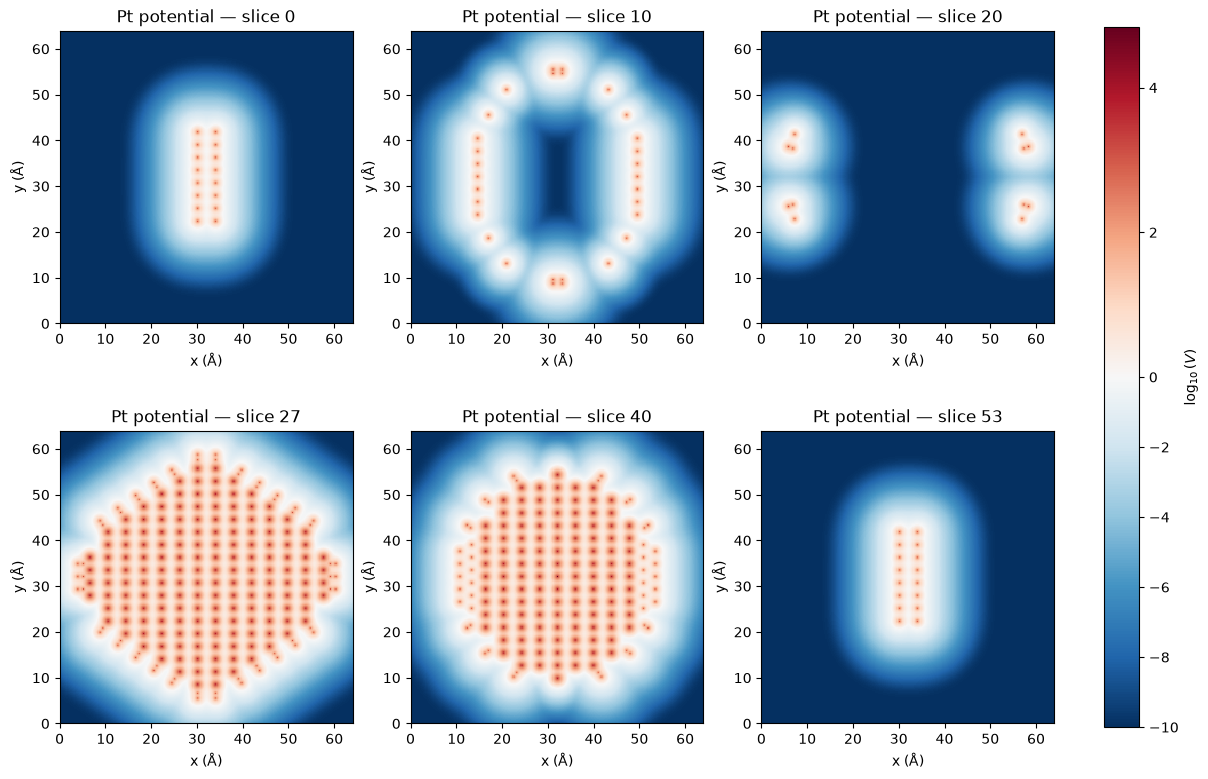

In [4]:
# Load QuScope potential mode 
model = np.load(data/ f"models/Pt5nm_cov_quscope.npz")
potentials = model["potentials"]

slice_ids = [0, 10, 20, 27, 40, 53] # Choose slices to plot

V_log = np.log10(potentials[slice_ids] + 1e-10) # take the log og data 
vmin = V_log.min() # determine min value in layers for cbar
vmax = V_log.max() # determine max value in layers for cbar
norm = TwoSlopeNorm(vmin=vmin,vcenter=0,vmax=vmax) # set neutral colour = 0 in cbar. 

fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
# Loops over and plot all the choosen layers 
for ax, i, V in zip(axes.flat, slice_ids, V_log):

    im = ax.imshow(V,extent=[0, 64, 0, 64],origin="lower",
        interpolation="nearest", norm=norm, cmap="RdBu_r")

    ax.set_title(f"Pt potential — slice {i}")
    ax.set_xlabel("x (Å)")
    ax.set_ylabel("y (Å)")

fig.colorbar(im, ax=axes, label=r"$\log_{10}(V)$", shrink=0.9)
plt.show()

---
# Simulate TEM Images
---

### Quscope Imaging

In [5]:
# Load exit_wave as data from the data folder.
result_file = (data / "exit_waves" / "Pt5nm_quscope_result.npz")
exit_wave = np.load(result_file)

# Extract all relevant wave information from the exit_wave.
wave = exit_wave["wave_function"]
amp = exit_wave["amplitude"]
phase = exit_wave["phase"]
intens = exit_wave["intensity"]

# Extract the resolution of the multislice calc. 
grid_size = int(exit_wave["grid_size"])
pixel_size = float(exit_wave["pixel_size"])
field_of_view = float(exit_wave["field_of_view"])

# Print the data
print("Exit-wave stats:")
print(f"  shape   : {wave.shape}")
print(f"  |ψ|_max : {amp.max():.4f}")
print(f"  ∑|ψ|²   : {intens.sum():.4f}")
print(f"  grid    : {grid_size} × {grid_size}")
print(f"  pixel   : {pixel_size:.4f} Å")
print(f"  FOV     : {field_of_view:.2f} Å")

Exit-wave stats:
  shape   : (256, 256)
  |ψ|_max : 0.0084
  ∑|ψ|²   : 1.0000
  grid    : 256 × 256
  pixel   : 0.2500 Å
  FOV     : 64.00 Å


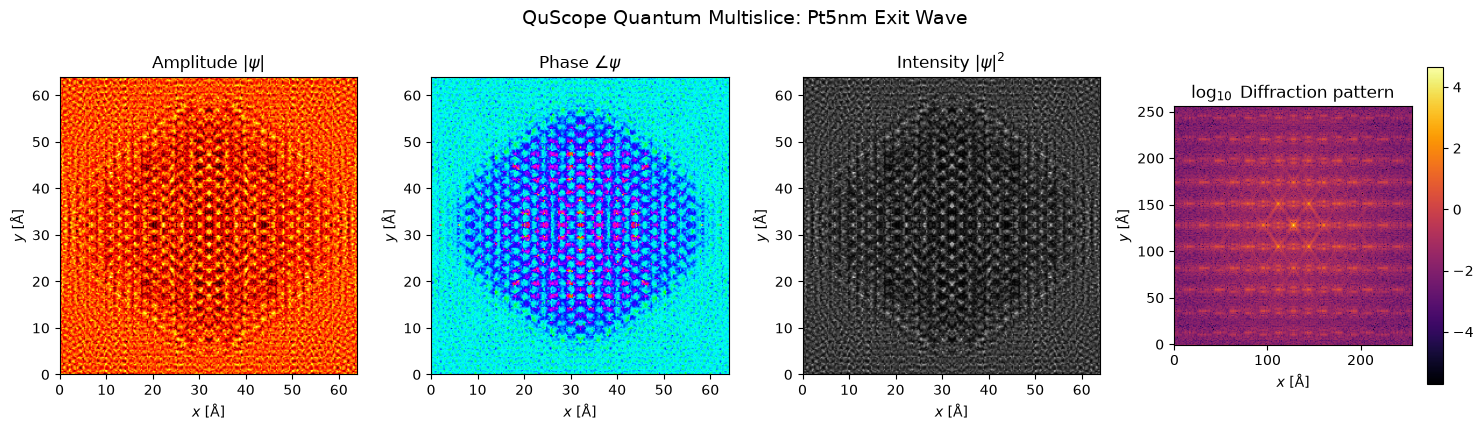

In [6]:
# Plot the all the wave information  
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Confine the plot to the field of view 
extent = [0, field_of_view, 0, field_of_view]
kw = dict(origin="lower", extent=extent)

# Plot the exit_wave amp
axes[0].imshow(amp, cmap="hot", **kw,)
axes[0].set_title(r"Amplitude $|\psi|$")

# Plot the exit_wave phase
axes[1].imshow(phase, cmap="hsv", **kw,)
axes[1].set_title(r"Phase $\angle\psi$")

# Plot the exit_wave intensity
axes[2].imshow(intens, cmap="gray", **kw,)
axes[2].set_title(r"Intensity $|\psi|^2$")

# Plot the exit_wave diffraction pattern
diff_patern = np.fft.fftshift(np.abs(np.fft.fft2(wave)) ** 2)

im = axes[3].imshow(np.log10(diff_patern + 1e-10), cmap="inferno", origin="lower",)
axes[3].set_title(r"$\log_{10}$ Diffraction pattern")
plt.colorbar(im, ax=axes[3])

# Plot settings
for ax in axes:
    ax.set_xlabel(r"$x$ [Å]")
    ax.set_ylabel(r"$y$ [Å]")

plt.suptitle("QuScope Quantum Multislice: Pt5nm Exit Wave", fontsize=14, y=1.02,)

plt.tight_layout()
plt.show()

### Comparison with abTEM

In [7]:
# Load the exit wave from /data
atom_ewave = abtem.from_zarr(str(data / "exit_waves" / "Pt5nm_ewave.zarr"))

In [8]:
# Creating Classical Contrast Transfer Function

# Abberation from Visions TEM "Prime" by Idan Biran.
energy = 300e3 # Abberations are based of 300keV
C10 = 55         # Defocus            # 55 Å
C30 = -14.72e4   # C3, Cs (spherical) # -14.72 µm
C50 = 7.606e7    # C5, C5 (spherical) # 7.606 mm

# Abberation from Visions TEM "Prime" by Idan Biran.
Cc = 1.6e-3 * 1e10 # Chromatic aberration in Å.
energy_spread = 0.105 # Use the best focal spread in eV
focal_spread = np.abs(Cc) * energy_spread / energy  # Focal spread for Titan.
focal_spread = focal_spread*np.sqrt(2) # Correction for temporal evelope in abTEM.

# inserting all abberation and agnle correction for the new TEM.
# Defocus (C10) must be added with cell_size, since abtem top of the image is C10 = 0.
aberration_coefficients = {"C10": C10, "C30": C30, "C50": C50}

# Create CTF.
ctf = abtem.CTF(aberration_coefficients=aberration_coefficients, energy=energy, focal_spread=focal_spread)

In [ ]:
# TEM images are the intensity of the exit_wave
im = atom_ewave.apply_ctf(ctf).intensity().compute()

In [ ]:
# Plotting TEM image
fig, ax = plt.subplots(figsize=(8, 6))

im.show(ax=ax,common_color_scale=True,cbar=True,cmap="Greys_r",)
ax.set_title("TEM Image: 55 Å", fontsize=14)

fig.tight_layout()
plt.show()

---
# Further Studies
---

### Add Optics as quantum gates

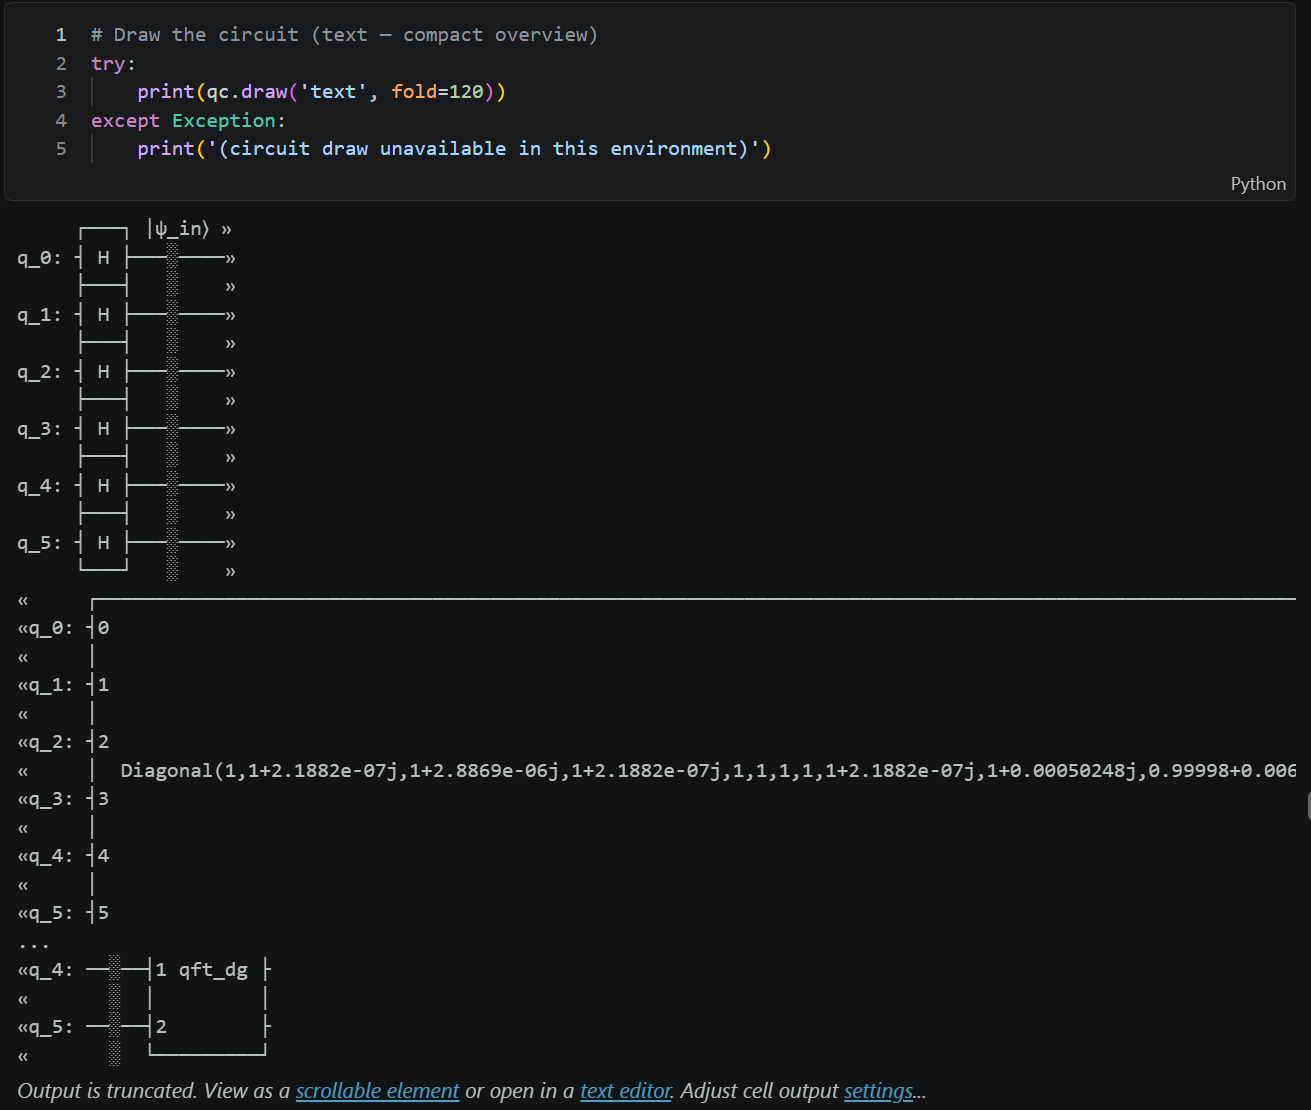

### Investigate Computation Noise

### Signal To Noise Ratio